## Setup

In [15]:
# Python ≥3.8 is required
import sys
assert sys.version_info >= (3, 8)

# Scikit-Learn ≥ 1.0 is required
import sklearn
assert sklearn.__version__ >= "1.0"

# Common imports
import numpy as np
import pandas as pd
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Precision options
np.set_printoptions(precision=2)
pd.options.display.float_format = '{:.3f}'.format

### Import data and training test split

Let's import the iris dataset first.

In [16]:
from sklearn.datasets import load_iris
iris = load_iris()

### Train-test splitting

As a first step let's split the dataset into training (2/3 of the data) and test set (1/3 of the data)

In [17]:

from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (100, 4)
Test set size: (50, 4)


### Feature scaling 

Then let's perform feature scaling (up to you whether you want to use standardisation or normalisation)

In [18]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")


Feature scaling completed.


## Supervised training using K-Nearest Neighbours

### Model creation and training

Now, evaluate the performance of your classifier using the confusion matrix. Compute and visualize the confusion matrix for our three classes

Now, let's create and train a `KNeighborsClassifier`.

We want the following properties for our classifier:
* check 7 neighbours by default for the `kneighbors` queries.
* use the Manhattan distance metric to identify neighbours
* use the Ball Tree algortihm to compute the nearest neighbours, with a `leaf_size` of 3. Check the Ball Tree algorithm documentation on scikit-learn for more details.

Check the `KNeighborsClassifier` documentation to identify the arguments to pass to the `KNeighborsClassifier` constructor.

In [19]:

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=7,
    metric='manhattan',
    algorithm='ball_tree',
    leaf_size=3
)

knn.fit(X_train, y_train)

print("Model trained successfully.")


Model trained successfully.


### Evaluation on the training set

Now, evaluate the performance of your classifier using the confusion matrix. Compute and visualize the confusion matrix for our three classes

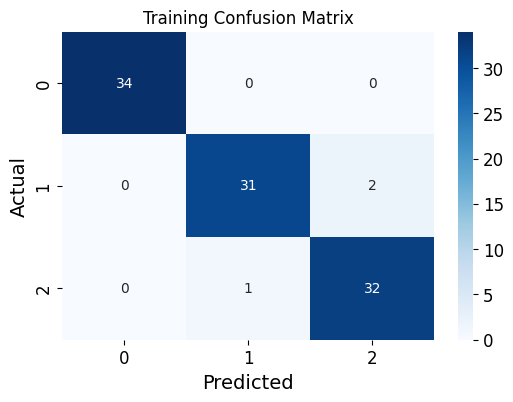

In [20]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_train_pred = knn.predict(X_train)

cm_train = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title("Training Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Compute precision, recall, and F1 score for each class prediction on the training set and print out a report.

In [21]:

from sklearn.metrics import classification_report

print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))


Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       0.97      0.94      0.95        33
           2       0.94      0.97      0.96        33

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



How does the result look like? Has anything been misclassified?


### Evaluation on the test set

Now make predictions on the test set, compute the confusion matrix for the test set. how does it compare to the one of the training set?

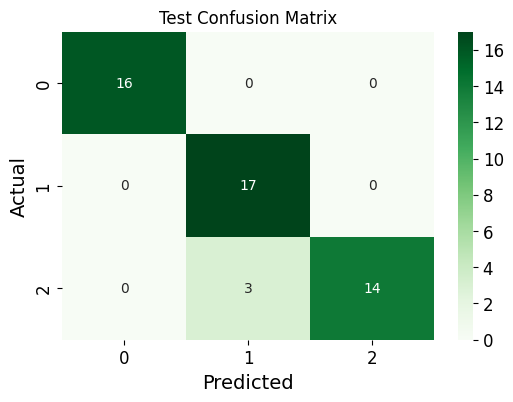

In [22]:

y_test_pred = knn.predict(X_test)

cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens')
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Compute precision, recall, and F1 score for each class prediction on the test set and print out a report.

In [23]:

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))


Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.85      1.00      0.92        17
           2       1.00      0.82      0.90        17

    accuracy                           0.94        50
   macro avg       0.95      0.94      0.94        50
weighted avg       0.95      0.94      0.94        50



## Unsupervised Learning using K-Means

Train K-means clusters on the entire iris dataset.

Train clusters with 2 to 6 clusters and use one of the metrics discussed in week 7 to show which is the optimal number of clusters

k = 2, Silhouette Score = 0.6810
k = 3, Silhouette Score = 0.5512
k = 4, Silhouette Score = 0.4976
k = 5, Silhouette Score = 0.4931
k = 6, Silhouette Score = 0.3678


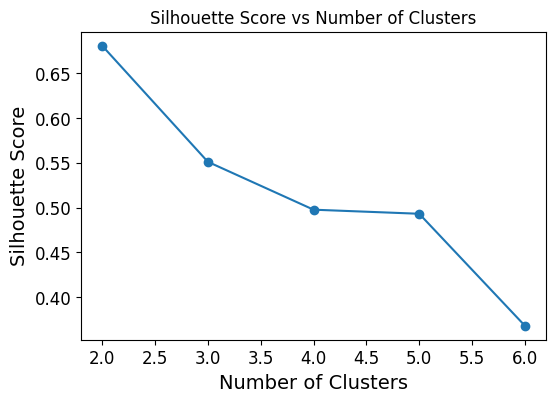

In [24]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(iris.data)
    score = silhouette_score(iris.data, labels)
    silhouette_scores.append(score)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(6,4))
plt.plot(range(2,7), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()


# Part B — TITANIC  Machine Learning Pipeline 
# Presentation of the problem 

This project aims to predict whether a passenger survived the Titanic disaster using demographic and travel-related features.  
This is a **supervised binary classification** problem where:

- **Target variable:** `Survived` (0 = did not survive, 1 = survived)
- **Goal:** Build and compare machine learning models that generalise well to unseen data.

Predicting survival can be framed as a risk prediction task where the model learns patterns from historical labelled examples.  
This pipeline follows standard applied ML practice: exploration → preparation → modelling → evaluation → conclusion.


In [25]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


# Load Dataset

In [26]:
import os
import pandas as pd

# Build path relative to notebook location
DATA_PATH = os.path.join("..", "data", "train.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


# Data Overview
## 2 Data exploration

In this section, we inspect the dataset structure, missing values, and key relationships with survival.
We aim to identify:
- feature types (numeric vs categorical),
- data quality issues (missingness),
- early signals that may influence survival.


# Basic Structure + Missingness

In [27]:
print("Shape:", df.shape)
display(df.info())

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing


Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

Cabin       687
Age         177
Embarked      2
dtype: int64

# Target Balance

In [28]:
df["Survived"].value_counts(normalize=True).rename("proportion")


Survived
0   0.616
1   0.384
Name: proportion, dtype: float64

# Key EDA Plots

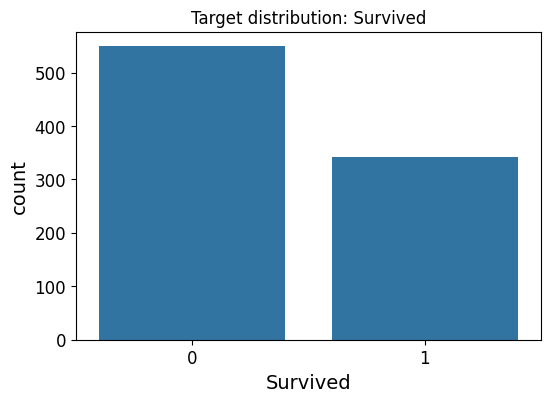

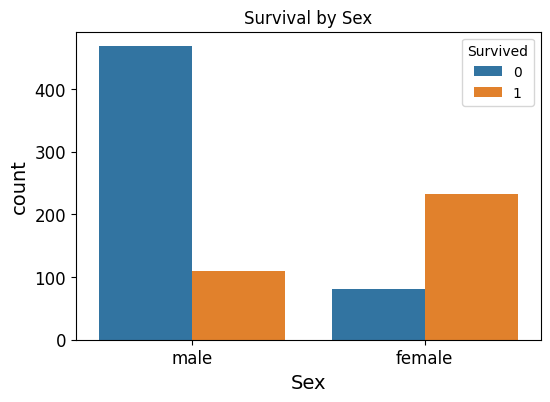

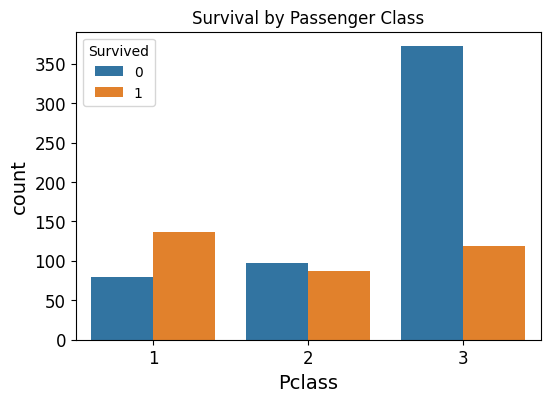

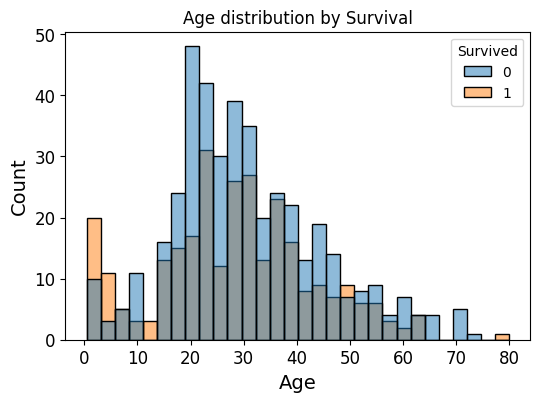

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Target distribution: Survived")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Sex")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=False)
plt.title("Age distribution by Survival")
plt.show()


### Exploration summary (brief)

Typical patterns observed in Titanic data include:
- **Sex** is strongly associated with survival (higher survival among females).
- **Passenger class (Pclass)** is associated with survival, often reflecting access to lifeboats and social advantage.
- **Age** may have a relationship with survival (e.g., children sometimes prioritised), but also contains missing values.

The dataset includes missingness (commonly `Age`, `Cabin`, and sometimes `Embarked`).  
Therefore, appropriate preprocessing (imputation + encoding) is necessary before modelling.


## 3 Data preparation

Steps:
1. Select features and target
2. Split into train/test with stratification (to preserve survival proportion)
3. Build preprocessing for numeric and categorical features:
   - Numeric: impute missing values (median) + standardise
   - Categorical: impute missing values (most frequent) + one-hot encode
4. Use pipelines to avoid data leakage and keep processing consistent.


In [30]:
# Feature/Target Split
target = "Survived"

# Drop high-missingness or ID-like columns commonly not used in basic baseline modelling
# (Cabin is very sparse; PassengerId is an identifier)
drop_cols = ["PassengerId", "Cabin"]

X = df.drop(columns=[target] + drop_cols)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (712, 9)
Test shape: (179, 9)


# Preprocessing Pipeline

In [31]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

numeric_features, categorical_features


(Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object'),
 Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object'))

## 4 Model selection

We compare two supervised classification models:

### Model 1 — Logistic Regression
A strong baseline model that works well when relationships are approximately linear in feature space.
It is interpretable and often competitive after proper preprocessing.

### Model 2 — Random Forest
An ensemble of decision trees that can capture non-linear relationships and feature interactions.
It is robust and often improves performance when patterns are complex.


# Define Pipelines

In [32]:
log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])


# Cross-Validation Comparison

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use ROC-AUC as a strong metric for binary classification
log_auc = cross_val_score(log_reg, X_train, y_train, cv=cv, scoring="roc_auc")
rf_auc = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc")

print("Logistic Regression CV ROC-AUC:", log_auc.mean(), "+/-", log_auc.std())
print("Random Forest CV ROC-AUC:", rf_auc.mean(), "+/-", rf_auc.std())


Logistic Regression CV ROC-AUC: 0.8711884914980527 +/- 0.020832542635846264
Random Forest CV ROC-AUC: 0.8803375975006069 +/- 0.023138113951947047


## 5) Evaluation on the test set (4 points)

We train both models on the training set and evaluate on the held-out test set.
We report:
- confusion matrix
- precision / recall / F1 (classification report)
- ROC-AUC
- ROC curve


# Fit + Predict + Reports


===== Logistic Regression =====

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       110
           1       0.75      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



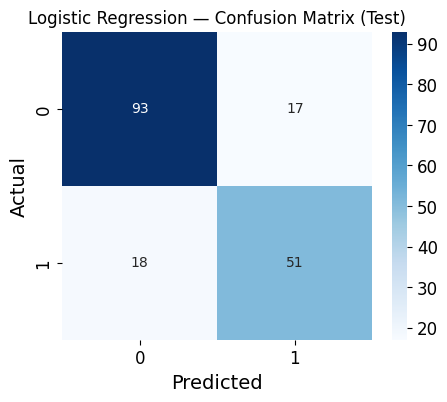

Test ROC-AUC: 0.8574

===== Random Forest =====

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       110
           1       0.82      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



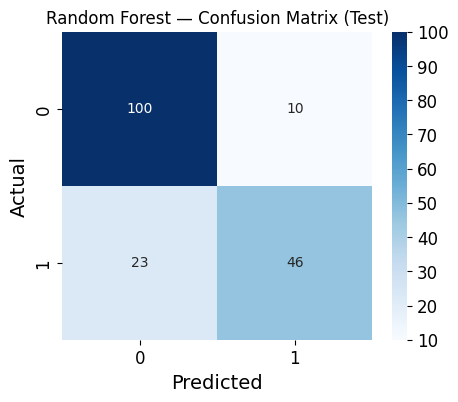

Test ROC-AUC: 0.8478


In [34]:
def evaluate_model(model, X_train, y_train, X_test, y_test, title="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # predicted probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    print(f"\n===== {title} =====")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{title} — Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
        print("Test ROC-AUC:", round(auc, 4))
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        return fpr, tpr, auc
    return None, None, None

log_fpr, log_tpr, log_auc_test = evaluate_model(log_reg, X_train, y_train, X_test, y_test, "Logistic Regression")
rf_fpr, rf_tpr, rf_auc_test = evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest")


# ROC Curve Comparison

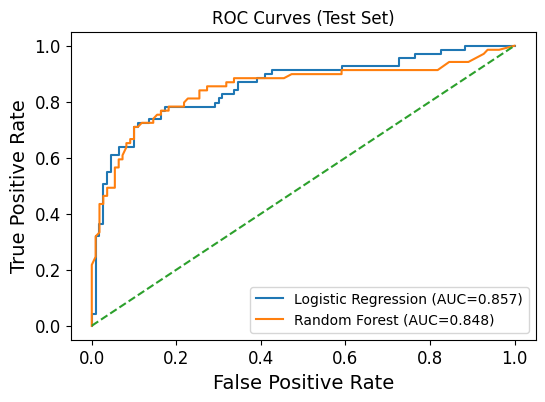

In [35]:
plt.figure(figsize=(6,4))

if log_fpr is not None:
    plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC={log_auc_test:.3f})")
if rf_fpr is not None:
    plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc_test:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.show()


## 6) Conclusion (10 points)

This project built a supervised ML pipeline to predict Titanic survival using structured passenger data.

### Model comparison
- **Logistic Regression** provides a strong baseline and is interpretable after one-hot encoding and scaling.
- **Random Forest** can capture non-linear effects and feature interactions, often improving predictive performance.

### Discussion
If Random Forest shows higher ROC-AUC and stronger F1-score for the survivor class, it suggests non-linear relationships exist in the data (e.g., interactions between class, sex, fare, and age).
If Logistic Regression performs similarly, it suggests the decision boundary is relatively simple after preprocessing.

### Limitations
- The dataset is historical and may contain confounding social factors not fully captured by available features.
- Some potentially informative columns were excluded (e.g., Cabin), mainly due to heavy missingness.
- Hyperparameter tuning was limited; further optimisation could improve results.

### Improvements
- Perform systematic hyperparameter tuning (e.g., GridSearchCV).
- Engineer features such as family size, title extraction from name, or ticket group size.
- Consider calibration and threshold tuning depending on the cost of false positives vs false negatives.

Overall, the pipeline demonstrates a complete ML workflow: exploration → preprocessing → modelling → evaluation → conclusions.
